# Bibliotecas

In [20]:
import os

In [21]:
import pandas as pd

In [143]:
import numpy as np

In [35]:
import seaborn as sns

In [38]:
import matplotlib.pyplot as plt

In [22]:
from sklearn.preprocessing import StandardScaler

In [32]:
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity

In [49]:
from factor_analyzer.factor_analyzer import calculate_kmo

In [69]:
from factor_analyzer import FactorAnalyzer

In [23]:
PATH = r'https://raw.githubusercontent.com/Wsm-erick/Diplomado/refs/heads/main/Modulo-III/Datasets'

# Ejercicio 1

## EDA

In [24]:
encuesta = pd.read_csv(os.path.join(PATH, 'data_practica_encuesta.csv'))

In [25]:
encuesta.shape

(25976, 14)

In [26]:
encuesta.head()

,Id,Servicio wifi a bordo,Hora de salida/llegada conveniente,Facilidad de reserva en línea,Ubicación de la puerta,Alimentos y bebidas,Embarque en línea,Comodidad del asiento,Entretenimiento a bordo,Servicio a bordo,Servicio de sala de piernas,Manejo de equipaje,Servicio de facturación,Limpieza
0,19556,5,4,3,4,3,4,3,5,5,5,5,2,5
1,90035,1,1,3,1,5,4,5,4,4,4,4,3,5
2,12360,2,0,2,4,2,2,2,2,4,1,3,2,2
3,77959,0,0,0,2,3,4,4,1,1,1,1,3,4
4,36875,2,3,4,3,4,1,2,2,2,2,2,4,4


In [27]:
encuesta.columns.tolist()

['Id',
 'Servicio wifi a bordo',
 'Hora de salida/llegada conveniente',
 'Facilidad de reserva en línea',
 'Ubicación de la puerta',
 'Alimentos y bebidas',
 'Embarque en línea',
 'Comodidad del asiento',
 'Entretenimiento a bordo',
 'Servicio a bordo',
 'Servicio de sala de piernas',
 'Manejo de equipaje',
 'Servicio de facturación',
 'Limpieza']

In [28]:
encuesta.loc[:,'Servicio wifi a bordo':].describe().T

,count,mean,std,min,25%,50%,75%,max
Servicio wifi a bordo,25976.0,2.724746,1.335384,0.0,2.0,3.0,4.0,5.0
Hora de salida/llegada conveniente,25976.0,3.046812,1.533371,0.0,2.0,3.0,4.0,5.0
Facilidad de reserva en línea,25976.0,2.756775,1.412951,0.0,2.0,3.0,4.0,5.0
Ubicación de la puerta,25976.0,2.977094,1.282133,1.0,2.0,3.0,4.0,5.0
Alimentos y bebidas,25976.0,3.215353,1.331506,0.0,2.0,3.0,4.0,5.0
Embarque en línea,25976.0,3.261665,1.355536,0.0,2.0,4.0,4.0,5.0
Comodidad del asiento,25976.0,3.449222,1.320090,1.0,2.0,4.0,5.0,5.0
Entretenimiento a bordo,25976.0,3.357753,1.338299,0.0,2.0,4.0,4.0,5.0
Servicio a bordo,25976.0,3.385664,1.282088,0.0,2.0,4.0,4.0,5.0
Servicio de sala de piernas,25976.0,3.350169,1.318862,0.0,2.0,4.0,4.0,5.0


In [29]:
N = encuesta.shape[0]

print('Proporción de missings...', end='\n\n')

for col in encuesta.columns:
    n = encuesta.loc[:, col].isna().sum()
    print(f'{col} -', n/N)

Proporción de missings...

Id - 0.0
Servicio wifi a bordo - 0.0
Hora de salida/llegada conveniente - 0.0
Facilidad de reserva en línea - 0.0
Ubicación de la puerta - 0.0
Alimentos y bebidas - 0.0
Embarque en línea - 0.0
Comodidad del asiento - 0.0
Entretenimiento a bordo - 0.0
Servicio a bordo - 0.0
Servicio de sala de piernas - 0.0
Manejo de equipaje - 0.0
Servicio de facturación - 0.0
Limpieza - 0.0


No hay valores vacíos.

In [30]:
scaler =  StandardScaler()
columns = encuesta.columns
encuesta_tr = scaler.fit_transform(encuesta)
encuesta_tr = pd.DataFrame(data=encuesta_tr, columns=columns)
encuesta_tr.head(10)

,Id,Servicio wifi a bordo,Hora de salida/llegada conveniente,Facilidad de reserva en línea,Ubicación de la puerta,Alimentos y bebidas,Embarque en línea,Comodidad del asiento,Entretenimiento a bordo,Servicio a bordo,Servicio de sala de piernas,Manejo de equipaje,Servicio de facturación,Limpieza
0,-1.208420,1.703853,0.621641,0.172143,0.797831,-0.161739,0.544692,-0.340303,1.227138,1.259170,1.250974,1.161716,-1.035348,1.298998
1,0.665483,-1.291598,-1.334871,0.172143,-1.542065,1.340348,0.544692,1.174774,0.479907,0.479178,0.492730,0.311739,-0.247517,1.298998
2,-1.399748,-0.542735,-1.987042,-0.535609,0.797831,-0.912783,-0.930768,-1.097842,-1.014556,0.479178,-1.782001,-0.538238,-1.035348,-0.974927
3,0.344405,-2.040460,-1.987042,-1.951114,-0.762100,-0.161739,0.544692,0.417235,-1.761787,-1.860800,-1.782001,-2.238193,-0.247517,0.541023
4,-0.747941,-0.542735,-0.030530,0.879895,0.017866,0.589304,-1.668498,-1.097842,-1.014556,-1.080807,-1.023758,-1.388216,0.540315,0.541023
5,-0.686735,0.206128,-0.030530,0.172143,0.017866,1.340348,1.282422,-0.340303,1.227138,0.479178,-0.265514,-2.238193,-1.823179,1.298998
6,0.383596,1.703853,1.273812,1.587647,1.577797,-0.161739,1.282422,1.174774,1.227138,1.259170,1.250974,1.161716,0.540315,-0.216952
7,0.858273,-0.542735,-0.682700,-0.535609,-0.762100,0.589304,0.544692,1.174774,0.479907,0.479178,0.492730,0.311739,1.328146,-0.216952
8,-0.996992,1.703853,-0.682700,-0.535609,-0.762100,1.340348,1.282422,1.174774,1.227138,-1.080807,-1.023758,1.161716,-0.247517,1.298998
9,-0.067099,-0.542735,-0.682700,-0.535609,-0.762100,-0.161739,0.544692,0.417235,0.479907,0.479178,0.492730,0.311739,1.328146,0.541023


### Prueba de esfericidad de Barlett

In [33]:
chi2, p = calculate_bartlett_sphericity(encuesta_tr)
print("Esfericidad de Bartlett")
print("Valor de Chi : ", chi2)
print("P - value : ", p)

Esfericidad de Bartlett
Valor de Chi :  134048.10599559
P - value :  0.0


> $H_{0}$ : La matriz de correlaciones es la identidad, es decir, no hay correlación entre variables. <br>
> $H_{1}$ : La matriz si tiene correlación significativa.

* *Si $\,p-value < 0.05$ entonces rechaza $H_{0}$ (hay correlación entre variables)*
* *Si $\,p-value ≥ 0.05$ entonces no rechaza $H_{0}$ (variables independientes)*

La prueba de esfericidad de Bartlett fue significativa (p < 0.05), lo que indica que la matriz de correlaciones difiere significativamente de la matriz identidad, justificando la aplicación de técnicas de reducción de dimensionalidad como el análisis de componentes principales.

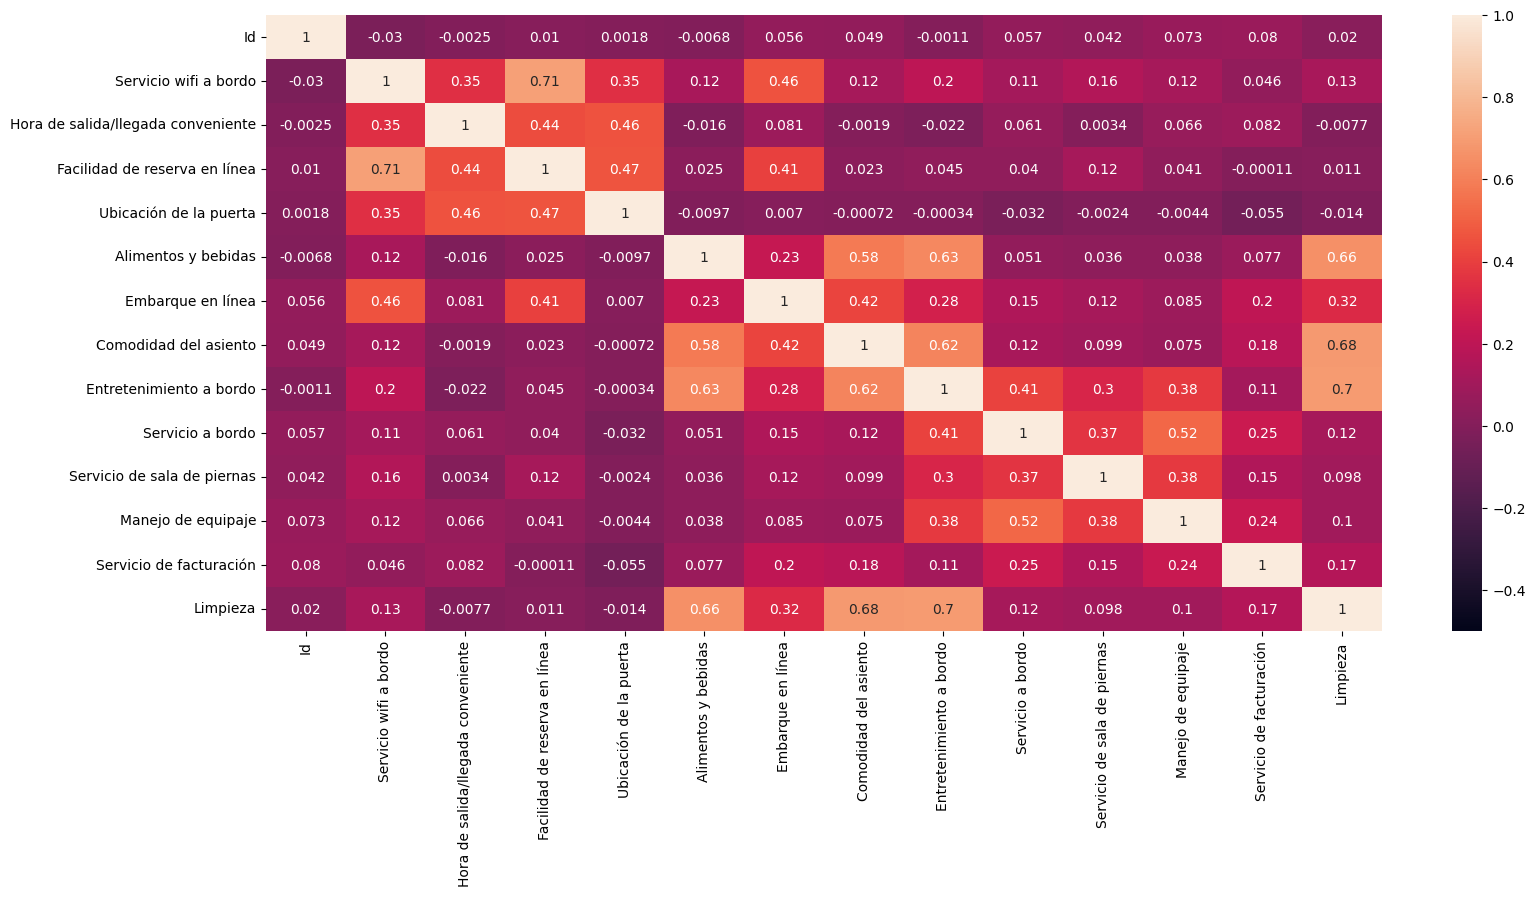

In [47]:
plt.figure(figsize=(18,8))
sns.heatmap(encuesta_tr.corr(), annot=True, vmax=1, vmin=-0.5)
plt.show()

De la matriz de correlación podemos deducir que existe una buena relación entre las variables, vamos aplicar la prueba KMO para reforzar el enunciado.

### Prueba KMO

In [55]:
kmo_all, kmo_model = calculate_kmo(encuesta_tr)
print("KMO Test Statisitc:", "{:.6f}".format(kmo_model))

KMO Test Statisitc: 0.759652


Estructura factorial adecuada

In [57]:
kmo_all.__len__()

14

In [59]:
encuesta_tr.shape[1]

14

In [68]:
pd.Series(kmo_all.tolist())

0     0.528672
1     0.742391
2     0.752037
3     0.687548
4     0.704245
5     0.837731
6     0.731142
7     0.825686
8     0.745286
9     0.717652
10    0.825903
11    0.726719
12    0.661351
13    0.819793
dtype: float64

* El índice Kaiser-Meyer-Olkin (KMO) obtuvo un valor de 0.76, lo que indica una adecuación muestral buena para la aplicación del análisis factorial. Asimismo, la prueba de esfericidad de Bartlett fue estadísticamente significativa (χ² = 134,048; p < 0.001), lo que evidencia que la matriz de correlaciones difiere significativamente de la matriz identidad. En conjunto, estos resultados justifican la aplicación del análisis factorial.

### No. de factores

In [72]:
fa = FactorAnalyzer(rotation = None, impute = "drop", n_factors=encuesta_tr.shape[1])

In [73]:
fa.fit(encuesta_tr)

/home/erick/Entorno/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,n_factors,14
,rotation,None
,method,'minres'
,use_smc,True
,is_corr_matrix,False
,bounds,"(0.005, ...)"
,impute,'drop'
,svd_method,'randomized'
,rotation_kwargs,{}


In [74]:
ev, _ = fa.get_eigenvalues()

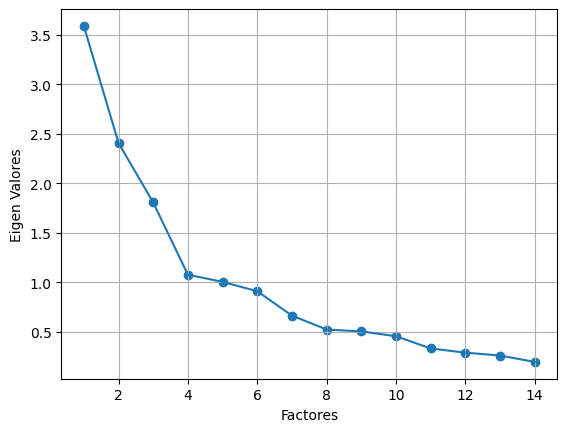

In [77]:
plt.scatter(range(1, encuesta_tr.shape[1]+1), ev)
plt.plot(range(1, encuesta_tr.shape[1]+1), ev)
plt.xlabel('Factores')
plt.ylabel('Eigen Valores')
plt.grid()

In [80]:
pd.Series(ev[ev > 1].tolist())

0    3.590307
1    2.406963
2    1.805530
3    1.075359
4    1.003151
dtype: float64

El número de componentes óptimo para nuestra muestra es de 5 ya que después de 5 componentes la varianza explicada es menor a una variable observada.

In [85]:
n_factors = ev[ev > 1].__len__()
n_factors

5

### Interpretar los Factores

In [86]:
#https://www.ibm.com/docs/es/spss-statistics/SaaS?topic=analysis-factor-rotation
#MÉTODOS DE ROTACION
fa = FactorAnalyzer(n_factors=n_factors,rotation=None)
fa.fit(encuesta_tr)

/home/erick/Entorno/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,n_factors,5
,rotation,None
,method,'minres'
,use_smc,True
,is_corr_matrix,False
,bounds,"(0.005, ...)"
,impute,'median'
,svd_method,'randomized'
,rotation_kwargs,{}


In [88]:
fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax')
fa.fit(encuesta_tr)

/home/erick/Entorno/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,n_factors,5
,rotation,'varimax'
,method,'minres'
,use_smc,True
,is_corr_matrix,False
,bounds,"(0.005, ...)"
,impute,'median'
,svd_method,'randomized'
,rotation_kwargs,{}


In [89]:
pd.DataFrame(fa.get_eigenvalues()[0],columns=['EigenValues'])

,EigenValues
0,3.590307
1,2.406963
2,1.805530
3,1.075359
4,1.003151
5,0.908686
6,0.662304
7,0.521551
8,0.501943
9,0.454025


### Cargas

In [90]:
cm = sns.light_palette("blue", as_cmap=True)

In [99]:
pd.Series(encuesta_tr.columns.tolist())

0                                     Id
1                  Servicio wifi a bordo
2     Hora de salida/llegada conveniente
3          Facilidad de reserva en línea
4                 Ubicación de la puerta
5                    Alimentos y bebidas
6                      Embarque en línea
7                  Comodidad del asiento
8                Entretenimiento a bordo
9                       Servicio a bordo
10           Servicio de sala de piernas
11                    Manejo de equipaje
12               Servicio de facturación
13                              Limpieza
dtype: object

In [100]:
fa.loadings_

array([[ 1.46875579e-03,  4.35935956e-02,  4.42776014e-03,
        -3.28416877e-03,  1.54968069e-01],
       [ 8.97002880e-02,  1.63088674e-01,  6.73534603e-01,
         4.20516061e-01, -8.63202592e-02],
       [-2.65301858e-02,  2.14909937e-02,  1.02304896e-01,
         6.76882779e-01,  1.27050982e-01],
       [-3.54525304e-02,  6.60250551e-02,  6.75122345e-01,
         5.71050321e-01, -9.37220964e-02],
       [-7.26526031e-04, -2.10445157e-02,  9.52866223e-02,
         6.79618101e-01, -9.55885711e-02],
       [ 7.65010855e-01,  8.35466807e-03,  5.03085404e-02,
         4.51704024e-03, -4.09434620e-02],
       [ 2.95648014e-01,  4.08664256e-02,  6.93200208e-01,
        -3.84447846e-02,  3.05483380e-01],
       [ 7.71816103e-01,  1.55387717e-02,  1.38805444e-01,
        -2.66232861e-02,  2.26712465e-01],
       [ 8.05422880e-01,  5.30270539e-01,  6.45036530e-02,
        -1.52592714e-02, -1.24163924e-01],
       [ 7.60445098e-02,  6.83138610e-01,  2.89747167e-02,
         6.31659191e-03

In [101]:
cargas = pd.DataFrame(fa.loadings_, index=encuesta_tr.columns).style.background_gradient(cmap=cm)

In [102]:
cargas

,0,1,2,3,4
Id,0.001469,0.043594,0.004428,-0.003284,0.154968
Servicio wifi a bordo,0.089700,0.163089,0.673535,0.420516,-0.086320
Hora de salida/llegada conveniente,-0.026530,0.021491,0.102305,0.676883,0.127051
Facilidad de reserva en línea,-0.035453,0.066025,0.675122,0.571050,-0.093722
Ubicación de la puerta,-0.000727,-0.021045,0.095287,0.679618,-0.095589
Alimentos y bebidas,0.765011,0.008355,0.050309,0.004517,-0.040943
Embarque en línea,0.295648,0.040866,0.693200,-0.038445,0.305483
Comodidad del asiento,0.771816,0.015539,0.138805,-0.026623,0.226712
Entretenimiento a bordo,0.805423,0.530271,0.064504,-0.015259,-0.124164
Servicio a bordo,0.076045,0.683139,0.028975,0.006317,0.223905


In [146]:
thr = 0.20  # tu umbral

for i, comp in enumerate(fa.loadings_.T):  # cada componente
    pares = [(var, float(loading)) for var, loading in zip(encuesta_tr.columns, comp)
             if abs(loading) > thr]

    pares.sort(key=lambda t: abs(t[1]), reverse=True)  # orden descendente

    print(f"Componente {i}:")
    for var, loading in pares:
        print(f"* {var} -> {loading:.4f}")
    print()

Componente 0:
* Limpieza -> 0.8457
* Entretenimiento a bordo -> 0.8054
* Comodidad del asiento -> 0.7718
* Alimentos y bebidas -> 0.7650
* Embarque en línea -> 0.2956

Componente 1:
* Manejo de equipaje -> 0.7090
* Servicio a bordo -> 0.6831
* Entretenimiento a bordo -> 0.5303
* Servicio de sala de piernas -> 0.5071

Componente 2:
* Embarque en línea -> 0.6932
* Facilidad de reserva en línea -> 0.6751
* Servicio wifi a bordo -> 0.6735

Componente 3:
* Ubicación de la puerta -> 0.6796
* Hora de salida/llegada conveniente -> 0.6769
* Facilidad de reserva en línea -> 0.5711
* Servicio wifi a bordo -> 0.4205

Componente 4:
* Servicio de facturación -> 0.4723
* Embarque en línea -> 0.3055
* Comodidad del asiento -> 0.2267
* Servicio a bordo -> 0.2239



* La variable Limpieza presenta una carga factorial alta en el componente 0, lo que indica una fuerte asociación con este factor, el cual puede interpretarse como una dimensión relacionada con la experiencia y calidad del servicio a bordo.
* Las variables fueron seleccionadas en cada factor considerando la magnitud absoluta de sus cargas factoriales mayor al umbral 0.20. Posteriormente, el signo de las cargas fue utilizado para interpretar la dirección de la relación entre las variables y el factor latente.

### Diferencia

In [147]:
fa.get_factor_variance()

(array([2.66299915, 1.5854749 , 1.45637409, 1.42772047, 0.5549842 ]),
 array([0.19021423, 0.11324821, 0.10402672, 0.10198003, 0.03964173]),
 array([0.19021423, 0.30346243, 0.40748915, 0.50946919, 0.54911091]))

In [148]:
diferencia = pd.DataFrame(fa.get_factor_variance(), index=['Variance','Proportional Var','Cumulative Var'])

In [149]:
diferencia

,0,1,2,3,4
Variance,2.662999,1.585475,1.456374,1.427720,0.554984
Proportional Var,0.190214,0.113248,0.104027,0.101980,0.039642
Cumulative Var,0.190214,0.303462,0.407489,0.509469,0.549111


- La primera fila representa la varianza explicada por cada factor
- La varianza proporcional es la varianza explicada por un factor de la varianza totaL
- La varianza acumulada no es más que la suma acumulada de las varianzas proporcionales de cada factor.
**En este caso, los 5 factores juntos son capaces de explicar el 54,91% de la varianza total**

### Comunidades

In [150]:
comunidades = pd.DataFrame(fa.get_uniquenesses(), index=encuesta_tr.columns, columns=['unicidad'])

In [151]:
comunidades

,unicidad
Id,0.974052
Servicio wifi a bordo,0.327422
Hora de salida/llegada conveniente,0.514056
Facilidad de reserva en línea,0.203711
Ubicación de la puerta,0.519459
Alimentos y bebidas,0.410461
Embarque en línea,0.335598
Comodidad del asiento,0.332684
Entretenimiento a bordo,0.050297
Servicio a bordo,0.476526


- La variable **Servicio a bordo** aproximadamente el 47% de su varianza se explica por todos los factores juntos.

# Ejercicio 2

## EDA

In [153]:
cancer = pd.read_csv(os.path.join(PATH, 'data_practica_cancer.csv'))

In [154]:
cancer.shape

(569, 32)

In [155]:
cancer.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
